# Smart Failure Detection Using Machine Learning

## AI4I 2020 Predictive Maintenance Dataset

### Infosys Springboard Virtual Internship 7.0

### Objective
To build a machine learning model that predicts machine failures using industrial sensor data and supports predictive maintenance.

In [3]:
pip install pandas numpy matplotlib seaborn scikit-learn streamlit joblib

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import joblib

In [5]:
df = pd.read_csv("ai4i2020.csv")
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


# Data Understanding

In this section, we explore the dataset to understand its structure, features, and target variable.

In [6]:
print("Dataset Shape:", df.shape)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset Shape: (10000, 14)
Rows: 10000
Columns: 14


In [7]:
df.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

### Observation

- Total records: 10,000
- Total columns: 14
- One categorical feature (Type)
- Remaining features are numerical.

In [9]:
df.dtypes

UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
UDI,10000.0,5000.50000,2886.895680,1.0,2500.75,5000.5,7500.25,10000.0
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.30,300.1,301.50,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.80,310.1,311.10,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.00,1503.0,1612.00,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.20,40.1,46.80,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.00,108.0,162.00,253.0
Machine failure,10000.0,0.03390,0.180981,0.0,0.00,0.0,0.00,1.0
TWF,10000.0,0.00460,0.067671,0.0,0.00,0.0,0.00,1.0
HDF,10000.0,0.01150,0.106625,0.0,0.00,0.0,0.00,1.0
PWF,10000.0,0.00950,0.097009,0.0,0.00,0.0,0.00,1.0


In [11]:
missing = df.isnull().sum()
print(missing)
print("Total Missing Values:", missing.sum())

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64
Total Missing Values: 0


In [12]:
duplicates = df.duplicated().sum()
print("Duplicate Records:", duplicates)

Duplicate Records: 0


# Data Preprocessing

The preprocessing steps include checking for missing values, duplicate records, encoding categorical variables, removing unnecessary columns, and scaling numerical features.

In [13]:
print(df["Type"].unique())
encoder = LabelEncoder()
df["Type"] = encoder.fit_transform(df["Type"])
print(df["Type"].unique())

<ArrowStringArray>
['M', 'L', 'H']
Length: 3, dtype: str
[2 1 0]


In [14]:
df = df.drop(["UDI","Product ID"], axis=1)

In [15]:
df.to_csv("cleaned_ai4i2020.csv", index=False)
print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


# Exploratory Data Analysis (EDA)

EDA helps us understand the relationships between different features and machine failures through visualizations.

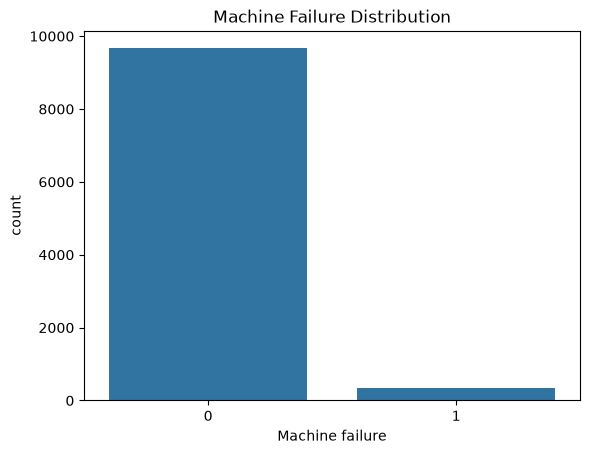

In [16]:
sns.countplot(x="Machine failure", data=df)
plt.title("Machine Failure Distribution")
plt.show()

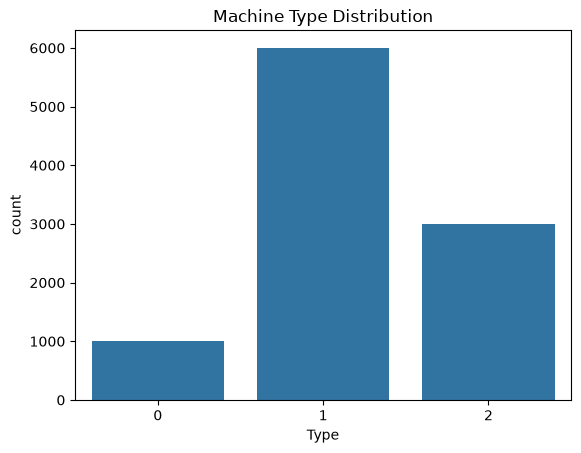

In [17]:
sns.countplot(x="Type", data=df)
plt.title("Machine Type Distribution")
plt.show()

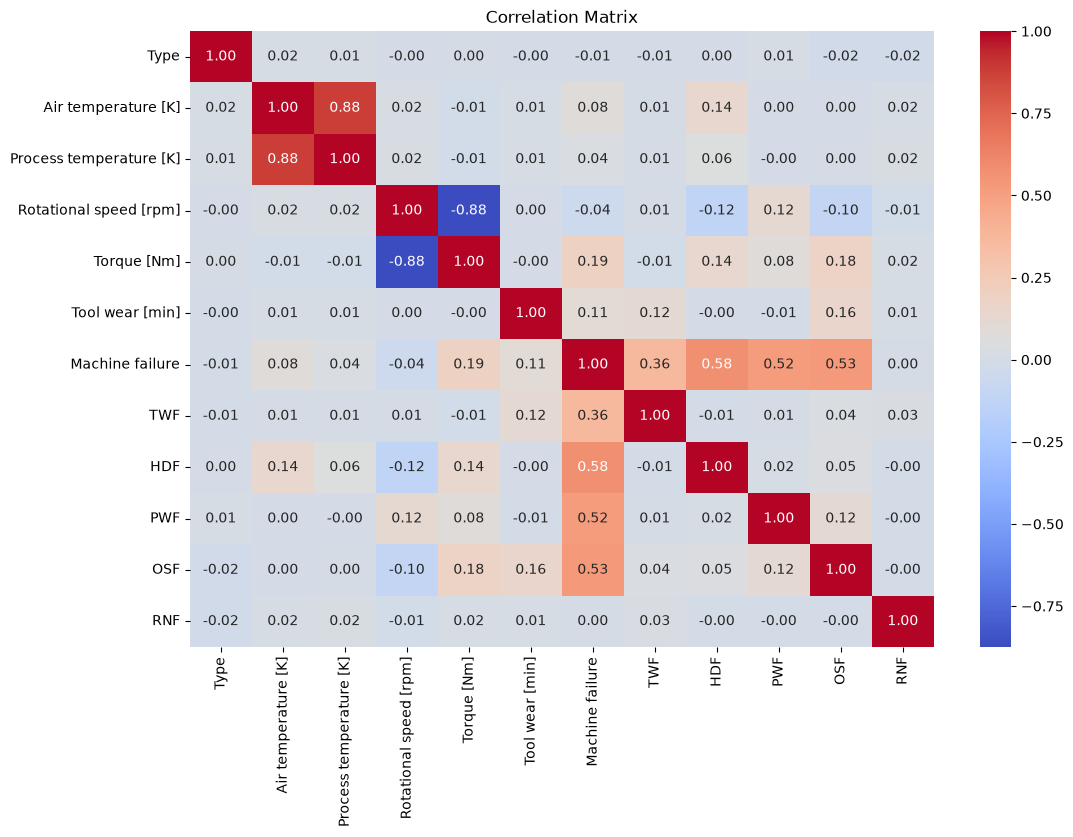

In [18]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

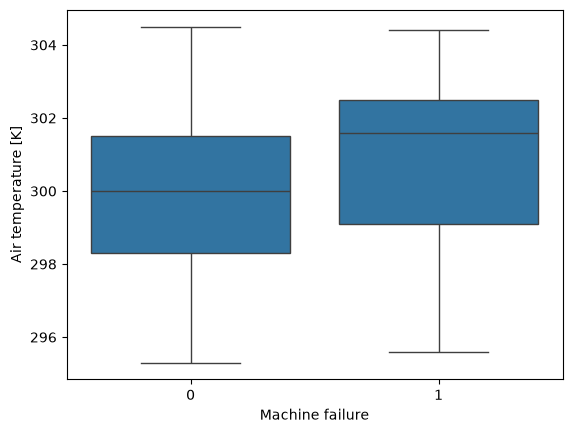

In [19]:
sns.boxplot(x="Machine failure",
            y="Air temperature [K]",
            data=df)
plt.show()

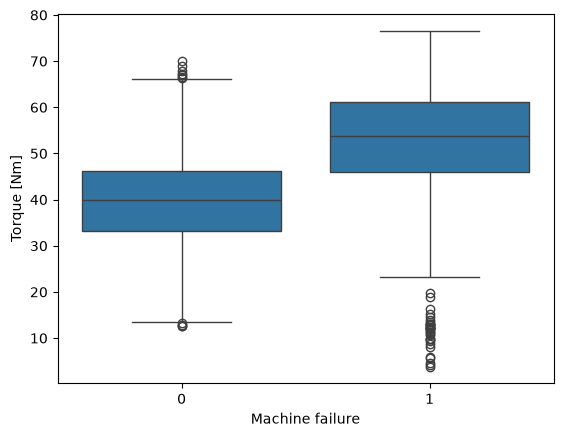

In [20]:
sns.boxplot(x="Machine failure",
            y="Torque [Nm]",
            data=df)
plt.show()

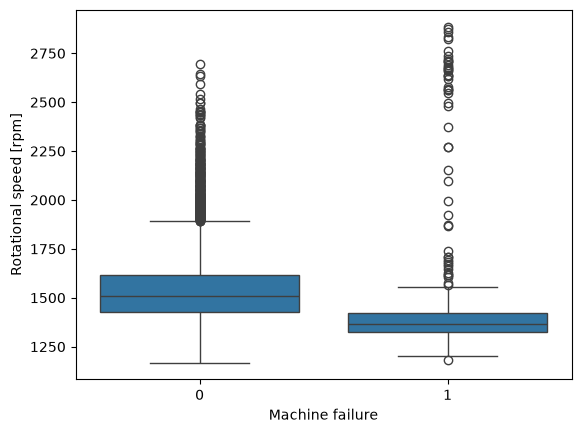

In [21]:
sns.boxplot(x="Machine failure",
            y="Rotational speed [rpm]",
            data=df)
plt.show()

In [22]:
X = df[
    [
        "Type",
        "Air temperature [K]",
        "Process temperature [K]",
        "Rotational speed [rpm]",
        "Torque [Nm]",
        "Tool wear [min]"
    ]
]
y = df["Machine failure"]

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print(X_train.shape)
print(X_test.shape)

(8000, 6)
(2000, 6)


In [24]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [25]:
import os
os.makedirs("models", exist_ok=True)
joblib.dump(scaler, "models/scaler.pkl")
print("Scaler saved successfully.")

Scaler saved successfully.


# Conclusion

- Dataset successfully loaded and understood.
- No missing values or duplicate records were found.
- The categorical feature was encoded.
- Unnecessary columns were removed.
- Exploratory Data Analysis was completed.
- The dataset was split into training and testing sets.
- Feature scaling was applied.
- The data is now ready for machine learning model training.

# Machine Learning Model Training

In this section, we train and evaluate multiple machine learning models to predict machine failures. We compare their performance and select the best-performing model.

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [27]:
lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

In [28]:
print("Accuracy:", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall:", recall_score(y_test, lr_pred))
print("F1 Score:", f1_score(y_test, lr_pred))

Accuracy: 0.973
Precision: 0.64
Recall: 0.26229508196721313
F1 Score: 0.37209302325581395


In [29]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

In [30]:
print("Accuracy:", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred))
print("Recall:", recall_score(y_test, dt_pred))
print("F1 Score:", f1_score(y_test, dt_pred))

Accuracy: 0.9785
Precision: 0.6363636363636364
Recall: 0.6885245901639344
F1 Score: 0.6614173228346457


In [31]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [32]:
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred))

Accuracy: 0.984
Precision: 0.8372093023255814
Recall: 0.5901639344262295
F1 Score: 0.6923076923076923


In [33]:
svm = SVC(probability=True, random_state=42)
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)

C:\Users\Aadya\anaconda3\envs\aiml_projects\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [34]:
print("Accuracy:", accuracy_score(y_test, svm_pred))
print("Precision:", precision_score(y_test, svm_pred))
print("Recall:", recall_score(y_test, svm_pred))
print("F1 Score:", f1_score(y_test, svm_pred))

Accuracy: 0.977
Precision: 0.8571428571428571
Recall: 0.29508196721311475
F1 Score: 0.43902439024390244


In [35]:
results = {
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "SVM"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, svm_pred)
    ]
}
comparison = pd.DataFrame(results)
comparison

,Model,Accuracy
0,Logistic Regression,0.9730
1,Decision Tree,0.9785
2,Random Forest,0.9840
3,SVM,0.9770


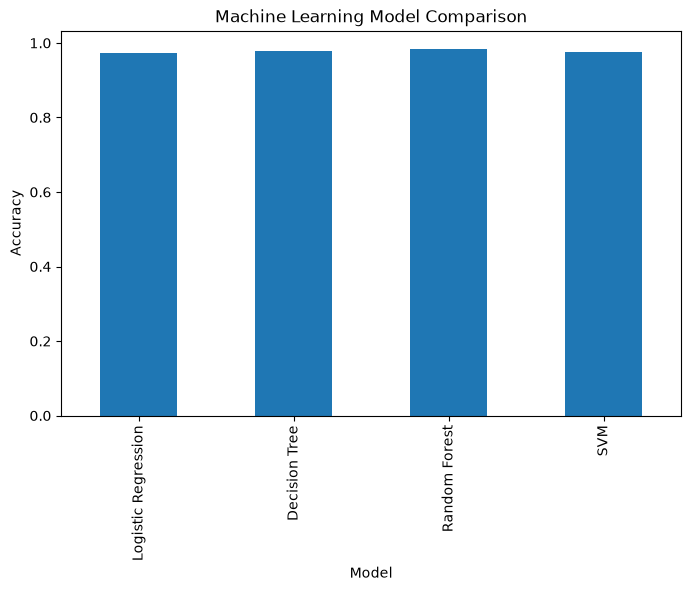

In [36]:
comparison.plot(
    x="Model",
    y="Accuracy",
    kind="bar",
    legend=False,
    figsize=(8,5)
)
plt.ylabel("Accuracy")
plt.title("Machine Learning Model Comparison")
plt.show()

## Best Model

After comparing all models, the Random Forest Classifier achieved the best performance based on accuracy and evaluation metrics. Therefore, it is selected for the final Smart Failure Detection system.

In [37]:
import joblib
joblib.dump(rf, "best_model.pkl")
print("Best model saved successfully.")

Best model saved successfully.


In [38]:
cm = confusion_matrix(y_test, rf_pred)
print(cm)

[[1932    7]
 [  25   36]]


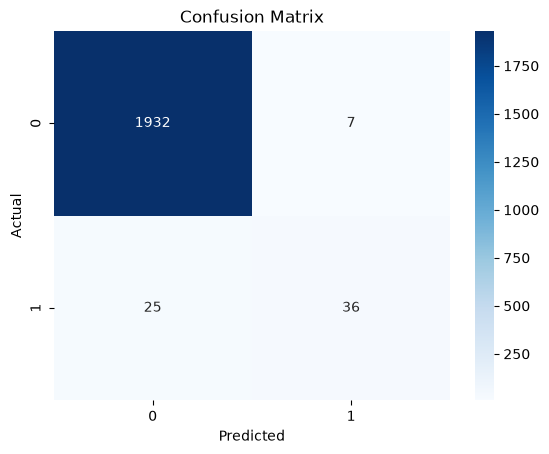

In [39]:
import seaborn as sns
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [40]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1939
           1       0.84      0.59      0.69        61

    accuracy                           0.98      2000
   macro avg       0.91      0.79      0.84      2000
weighted avg       0.98      0.98      0.98      2000



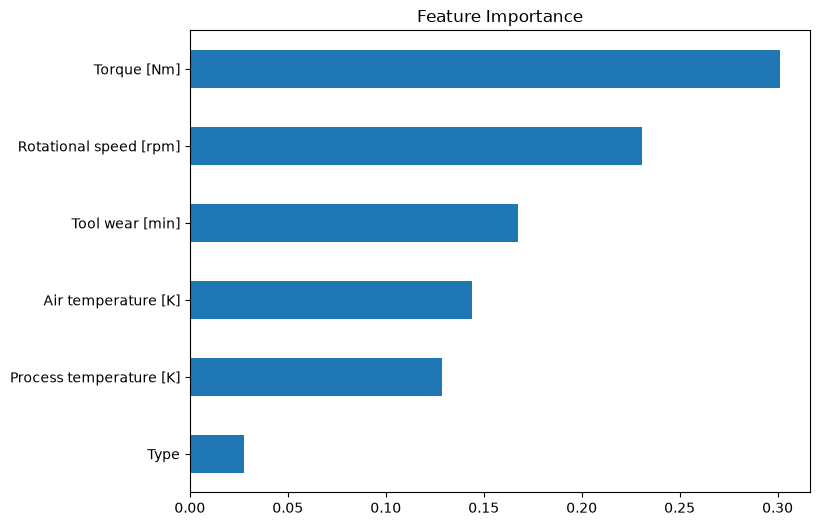

In [41]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)
importance.sort_values().plot(
    kind="barh",
    figsize=(8,6)
)
plt.title("Feature Importance")
plt.show()

# Conclusion

- Multiple machine learning models were trained and evaluated.
- The best-performing model was selected based on evaluation metrics.
- The trained model was saved for future prediction.
- The project is now ready for integration with the Streamlit dashboard.

In [42]:
import joblib
joblib.dump(rf, "best_model.pkl")
print("Best model saved successfully.")

Best model saved successfully.


In [43]:
loaded_model = joblib.load("best_model.pkl")
print("Model loaded successfully.")

Model loaded successfully.


In [44]:
print(X.columns)

Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]'],
      dtype='str')


In [45]:
sample = [[
    0,
    298.1,
    308.6,
    1551,
    42.8,
    5
]]
sample = scaler.transform(sample)

C:\Users\Aadya\anaconda3\envs\aiml_projects\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [46]:
type_mapping = {
    "L": 0,
    "M": 1,
    "H": 2
}
print(type_mapping)

{'L': 0, 'M': 1, 'H': 2}


In [47]:
prediction = rf.predict(sample)
print("Prediction:", prediction)

Prediction: [0]


In [48]:
probability = rf.predict_proba(sample)
print(probability)

[[1. 0.]]


In [49]:
if prediction[0] == 0:
    print("Machine is Healthy")
else:
    print("Machine Failure Predicted")

Machine is Healthy


In [50]:
print(f"Failure Probability: {probability[0][1]*100:.2f}%")

Failure Probability: 0.00%


In [51]:
health_score = 100 - (probability[0][1] * 100)
print(f"Machine Health Score: {health_score:.2f}%")

Machine Health Score: 100.00%


In [52]:
if probability[0][1] > 0.8:
    print("🔴 Immediate Maintenance Required")
elif probability[0][1] > 0.5:
    print("🟠 Schedule Maintenance Soon")
else:
    print("🟢 Machine is Operating Normally")

🟢 Machine is Operating Normally


In [53]:
sample = [[
    2,      # Machine Type 
    315,    # Air Temperature
    325,    # Process Temperature
    2800,   # High RPM
    75,     # High Torque
    250     # High Tool Wear
]]
sample = scaler.transform(sample)
prediction = rf.predict(sample)
probability = rf.predict_proba(sample)
print("Prediction:", prediction)
print("Probability:", probability)
if prediction[0] == 0:
    print("Machine is Healthy")
else:
    print("Machine Failure Predicted")
health_score = 100 - (probability[0][1] * 100)
print(f"Machine Health Score: {health_score:.2f}%")

Prediction: [1]
Probability: [[0.25 0.75]]
Machine Failure Predicted
Machine Health Score: 25.00%


C:\Users\Aadya\anaconda3\envs\aiml_projects\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [54]:
import pandas as pd
comparison = pd.DataFrame({
    "Model": ["Logistic Regression","Decision Tree","Random Forest","SVM"],
    "Accuracy":[
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, svm_pred)
    ]
})
comparison.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
2,Random Forest,0.9840
1,Decision Tree,0.9785
3,SVM,0.9770
0,Logistic Regression,0.9730


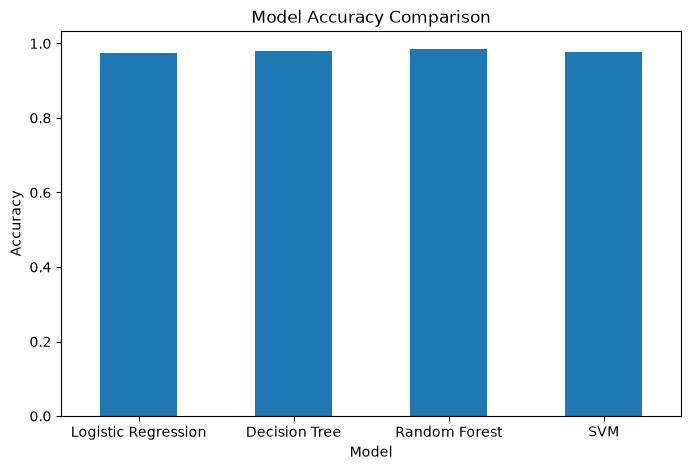

In [55]:
comparison.plot(
    x="Model",
    y="Accuracy",
    kind="bar",
    legend=False,
    figsize=(8,5)
)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=0)
plt.show()

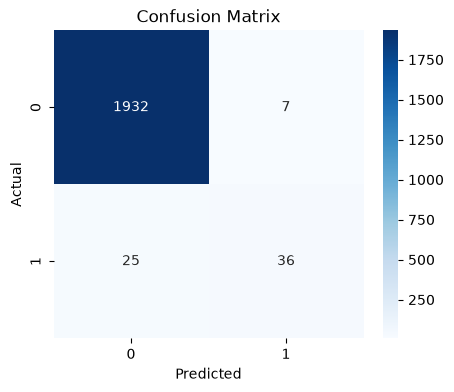

In [56]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [57]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1939
           1       0.84      0.59      0.69        61

    accuracy                           0.98      2000
   macro avg       0.91      0.79      0.84      2000
weighted avg       0.98      0.98      0.98      2000



In [58]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})
importance.sort_values(by="Importance", ascending=False)

,Feature,Importance
4,Torque [Nm],0.301376
3,Rotational speed [rpm],0.230589
5,Tool wear [min],0.167549
1,Air temperature [K],0.144058
2,Process temperature [K],0.128892
0,Type,0.027536
